## **AdaBoost  Hyperparameter Tuning**

## **Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

### **Create Dataset**

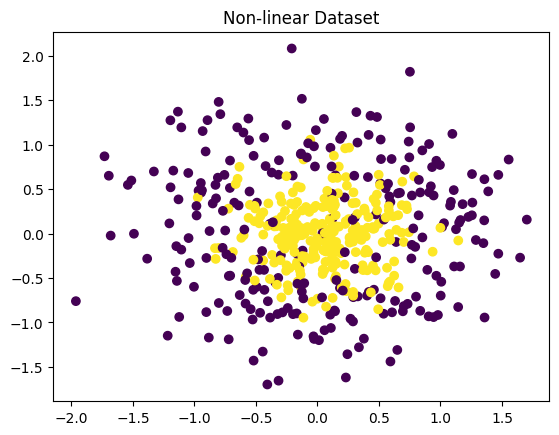

In [2]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Non-linear Dataset")
plt.show()

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Basic AdaBoost Model

In [5]:
abc = AdaBoostClassifier()

score = np.mean(cross_val_score(abc, X_train, y_train, cv=10, scoring='accuracy'))
print("Baseline Accuracy:", score)

Baseline Accuracy: 0.7899999999999999


In [6]:
abc.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


## Decision Boundary Visualization

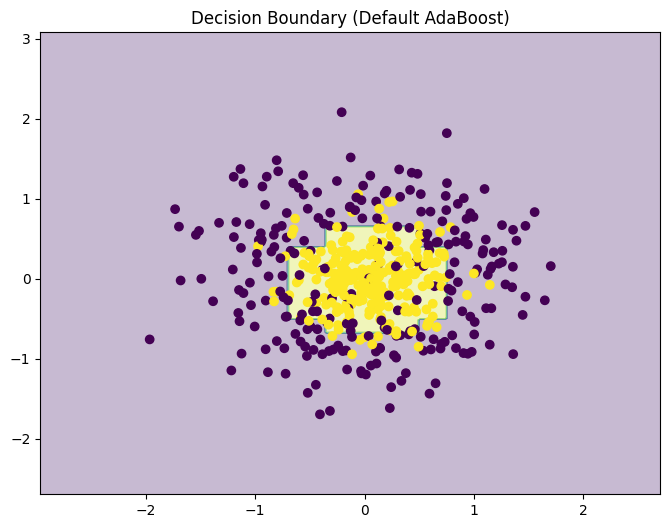

In [7]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(8,6))
    
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')
    plt.title("Decision Boundary (Default AdaBoost)")
    plt.show()

plot_decision_boundary(abc)

Manual Hyperparameter Tuning

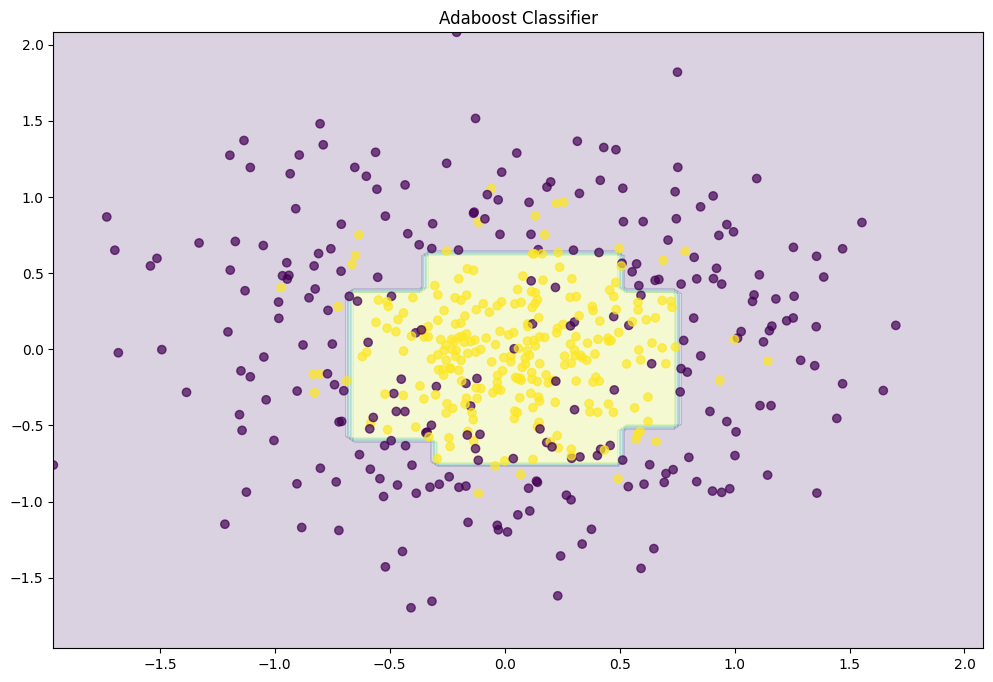

In [9]:
abc = AdaBoostClassifier(
    n_estimators=1500,
    learning_rate=0.1
)

abc.fit(X_train, y_train)
plot_decision_boundary(abc)

## Grid Search

In [13]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [10, 50, 100, 500],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

# Model
model = AdaBoostClassifier(random_state=42)

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid.fit(X_train, y_train)

# Results
print("Best Score:", grid.best_score_)
print("Best Params:", grid.best_params_)

Best Score: 0.82
Best Params: {'learning_rate': 1.0, 'n_estimators': 500}


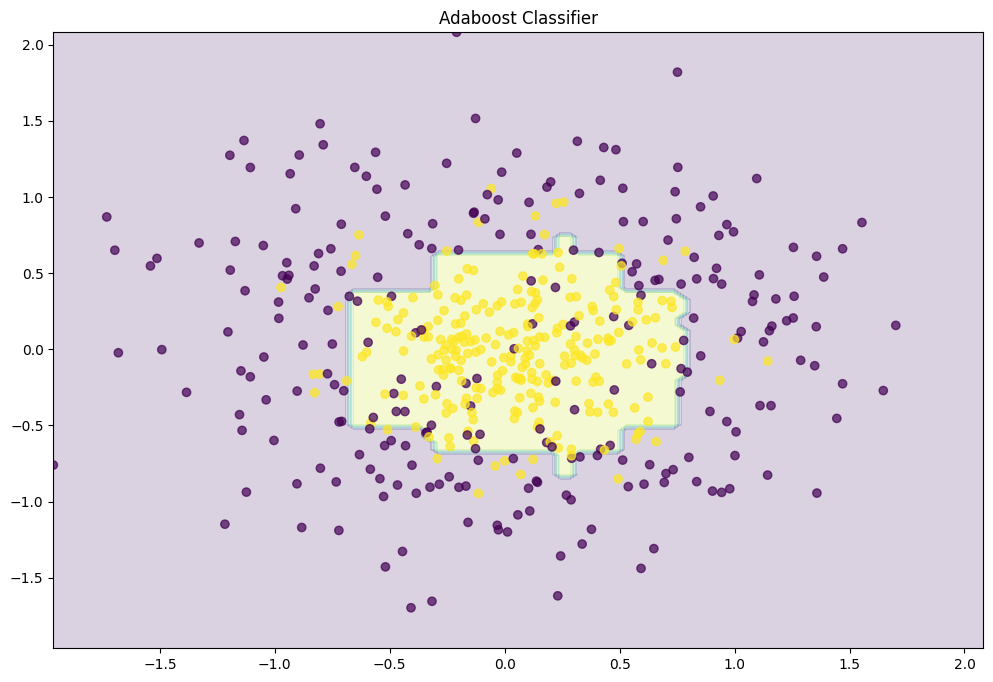

In [14]:
# Train best model
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)
plot_decision_boundary(best_model)